<a href="https://colab.research.google.com/github/opherdonchin/BayesShortCourse/blob/main/sleep/solved/08_lognormal_distributional.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sleep deprivation 8 — Distributional lognormal model

Let residual variability itself differ by participant, not just the mean trajectory.

## Setup

This course pins PyMC and the modular ArviZ packages for reproducibility because their APIs can change across major versions.

In [1]:
%pip install -q \
    "pandas==2.2.3" \
    "pymc==6.3.2" \
    "arviz-base==1.3.0" \
    "arviz-stats==1.3.2" \
    "arviz-plots[matplotlib]==1.3.1"

Note: you may need to restart the kernel to use updated packages.


D:\Repositories\BayesShortCourse\tmp\colabenv\Scripts\python.exe: No module named pip


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import xarray as xr
import pymc as pm
import arviz_base as azb
import arviz_plots as azp
import arviz_stats as azs

RANDOM_SEED = 20260924
azp.style.use("arviz-variat")

print("PyMC:", pm.__version__)
print("arviz-base:", azb.__version__)
print("arviz-plots:", azp.__version__)
print("arviz-stats:", azs.__version__)

g++ not available, if using conda: `conda install gxx`


PyMC: 6.3.2
arviz-base: 1.3.0
arviz-plots: 1.3.1
arviz-stats: 1.3.2


## Data

The original study contains two adaptation/training days followed by a baseline measurement and then seven nights of severe sleep restriction. You can read about the original study here: [Belenky J Sleep Res. 2003](https://doi.org/10.1046/j.1365-2869.2003.00337.x)

Following the chapter, we drop original days 0–1 and subtract 2 from the remaining day number. Therefore **`Days = 0` is the baseline measurement before sleep deprivation begins**.

That zero point is scientifically meaningful, so every model in this sequence keeps `Days` on its natural scale (no centering). The intercept prior is therefore a prior on baseline reaction time rather than reaction time at the average deprivation day.

In [3]:
DATA_URL = "https://raw.githubusercontent.com/vincentarelbundock/Rdatasets/master/csv/lme4/sleepstudy.csv"

sleep = pd.read_csv(DATA_URL).drop(columns="rownames")
sleep = sleep.loc[sleep["Days"] >= 2].copy()
sleep["Days"] = sleep["Days"] - 2
sleep["Subject"] = sleep["Subject"].astype(str)
sleep = sleep.reset_index(drop=True)

print(f"{sleep['Subject'].nunique()} participants, {len(sleep)} observations")
print(f"Days: {sleep['Days'].min()} to {sleep['Days'].max()}")
sleep.head()

18 participants, 144 observations
Days: 0 to 7


,Reaction,Days,Subject
0,250.8006,0,308
1,321.4398,1,308
2,356.8519,2,308
3,414.6901,3,308
4,382.2038,4,308


In [4]:
# Plotting helpers (presentation only). Every plot uses the golf-notebook grammar:
# orange mean line, blue 50% and 90% HDI bands, black observed points.
DRAW_COLOR = "#12505e"  # darker shade of the band colour C0
LM_VISUALS = {
    "pe_line": {"color": "C1"},
    "ci_band": {"color": "C0"},
    "observed_scatter": {"color": "black", "alpha": 1, "zorder": 3, "s": 10},
}
PARTICIPANT_DAY = xr.Coordinates.from_pandas_multiindex(
    pd.MultiIndex.from_frame(sleep[["Subject", "Days"]], names=["participant", "day"]),
    "obs_id",
)

def add_interval_legend(target, line_label="mean", draws_label=None):
    """Compact one-row legend above an axis or above a whole panel grid."""
    handles = [
        Line2D([0], [0], color="C1", lw=1.6, label=line_label),
        Patch(facecolor="C0", alpha=0.9, label="50% HDI"),
        Patch(facecolor="C0", alpha=0.28, label="90% HDI"),
    ]
    if draws_label:
        handles.append(Line2D([0], [0], color=DRAW_COLOR, lw=0.9, label=draws_label))
    handles.append(Line2D([0], [0], marker="o", linestyle="none", color="black",
                          markersize=4.5, label="observed"))
    style = dict(ncols=len(handles), fontsize=8, handlelength=1.4, handletextpad=0.45,
                 columnspacing=0.9, frameon=False)
    if isinstance(target, plt.Figure):
        target.legend(handles=handles, loc="outside upper left", **style)
    else:
        target.legend(handles=handles, loc="lower left", bbox_to_anchor=(0, 1.01),
                      borderaxespad=0, **style)

def plot_population(dt, var, group="posterior"):
    """Single-panel trend of `var` against days, with all 144 raw observations."""
    pc = azp.plot_lm(
        dt, x="days", y=var, y_obs="Reaction", group=group, plot_dim="obs_id",
        ci_prob=(0.50, 0.90), ci_kind="hdi", point_estimate="mean", smooth=False,
        figure_kwargs={"figsize": (7, 4)}, visuals=LM_VISUALS,
    )
    ax = plt.gca()
    ax.set(xlabel="Days of sleep deprivation", ylabel="Reaction time (ms)")
    add_interval_legend(ax)
    return pc

def plot_participants(dt, group, var):
    """One panel per participant: bands for `var` against days, with that participant's data."""
    def reshape(ds):
        return ds.assign_coords(PARTICIPANT_DAY).unstack("obs_id")
    panels = xr.DataTree.from_dict({
        group: reshape(dt[group].to_dataset()),
        "observed_data": reshape(dt["observed_data"].to_dataset()),
        "constant_data": reshape(dt["constant_data"].to_dataset()),
    })
    pc = azp.plot_lm(
        panels, x="days", y=var, y_obs="Reaction", group=group, plot_dim="day",
        ci_prob=(0.50, 0.90), ci_kind="hdi", point_estimate="mean", smooth=False,
        cols=["participant"], col_wrap=6,
        figure_kwargs={"figsize": (11, 5.5), "sharex": True, "sharey": True},
        visuals={**LM_VISUALS, "xlabel": False, "ylabel": False},
    )
    fig = pc.viz["figure"].item()
    fig.supxlabel("Days of sleep deprivation")
    fig.supylabel("Reaction time (ms)")
    add_interval_legend(fig)
    return pc

In [5]:
participants = sorted(sleep["Subject"].unique(), key=int)
participant_idx = sleep["Subject"].map({p: i for i, p in enumerate(participants)}).to_numpy()

## 8.1 Modeling residual heterogeneity

Do participants differ in residual variability as well as in their mean reaction-time trajectories?

$$\log(\sigma_i)=\gamma_0+v_{s[i]}.$$

The mean trajectory still has varying intercepts and slopes, as in notebook 7. This notebook's group-level SD rates for the mean (3 and 5, rather than 6 and 10) are a separate refit choice made when the sigma component was added; both represent similarly broad assumptions.

In [6]:
coords = {"obs_id": np.arange(len(sleep)), "participant": participants}

with pm.Model(coords=coords) as model:
    days = pm.Data("days", sleep["Days"].to_numpy(), dims="obs_id")
    pidx = pm.Data("participant_idx", participant_idx, dims="obs_id")

    intercept = pm.Normal("intercept", mu=5.5, sigma=0.55)
    slope = pm.Normal("slope", mu=0, sigma=0.20)

    participant_intercept_sd = pm.Exponential("participant_intercept_sd", lam=3)
    participant_intercept_z = pm.Normal("participant_intercept_z", 0, 1, dims="participant")
    participant_intercept = pm.Deterministic(
        "participant_intercept",
        participant_intercept_sd * participant_intercept_z,
        dims="participant",
    )

    participant_slope_sd = pm.Exponential("participant_slope_sd", lam=5)
    participant_slope_z = pm.Normal("participant_slope_z", 0, 1, dims="participant")
    participant_slope = pm.Deterministic(
        "participant_slope",
        participant_slope_sd * participant_slope_z,
        dims="participant",
    )

    # log-linear model for the residual scale, with its own participant term
    sigma_intercept = pm.Normal("sigma_intercept", mu=0, sigma=0.30)
    participant_sigma_sd = pm.Exponential("participant_sigma_sd", lam=3)
    participant_sigma_z = pm.Normal("participant_sigma_z", 0, 1, dims="participant")
    participant_sigma = pm.Deterministic(
        "participant_sigma",
        participant_sigma_sd * participant_sigma_z,
        dims="participant",
    )
    residual_scale = pm.Deterministic(
        "residual_scale",
        pm.math.exp(sigma_intercept + participant_sigma),
        dims="participant",
    )
    population_residual_scale = pm.Deterministic(
        "population_residual_scale", pm.math.exp(sigma_intercept)
    )

    population_mu = pm.Deterministic(
        "population_mu", intercept + slope * days, dims="obs_id"
    )
    mu = pm.Deterministic(
        "mu",
        population_mu
        + participant_intercept[pidx]
        + participant_slope[pidx] * days,
        dims="obs_id",
    )
    sigma = pm.Deterministic("sigma", residual_scale[pidx], dims="obs_id")

    mean_rt = pm.Deterministic(
        "mean_rt", pm.math.exp(mu + sigma**2 / 2), dims="obs_id"
    )
    population_mean_rt = pm.Deterministic(
        "population_mean_rt",
        pm.math.exp(population_mu + population_residual_scale**2 / 2),
        dims="obs_id",
    )

    pm.LogNormal(
        "Reaction",
        mu=mu,
        sigma=sigma,
        observed=sleep["Reaction"].to_numpy(),
        dims="obs_id",
    )

Before fitting, ask what reaction times the priors make plausible. Each panel is one participant. The bands are the prior predictive distribution of a single new reaction-time measurement on each day. The black points are that participant's data, shown only as a reference: they do not condition the prior.

Sampling: [Reaction, intercept, participant_intercept_sd, participant_intercept_z, participant_sigma_sd, participant_sigma_z, participant_slope_sd, participant_slope_z, sigma_intercept, slope]


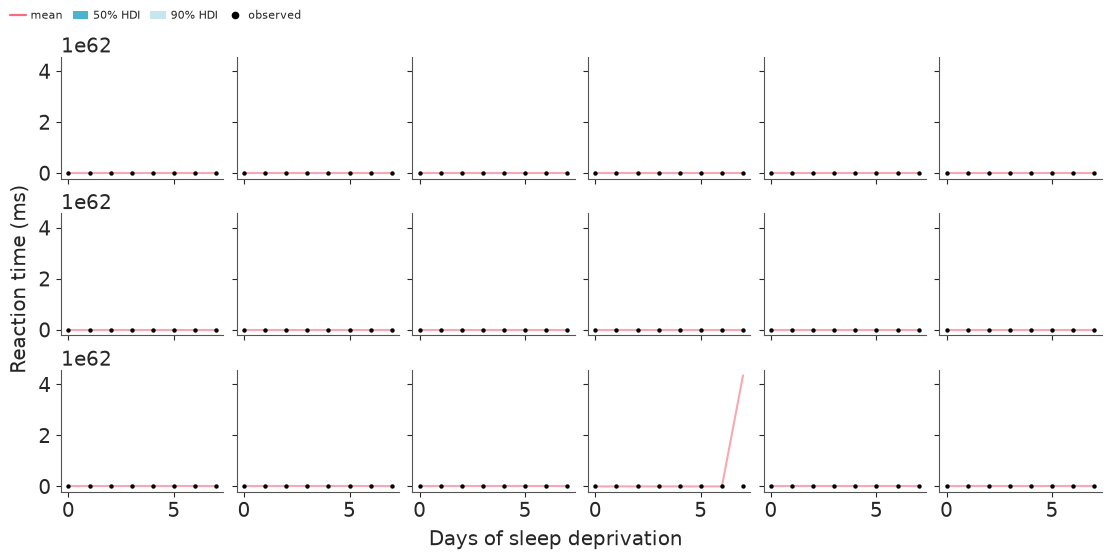

In [7]:
with model:
    prior = pm.sample_prior_predictive(
        draws=500, var_names=["Reaction"], random_seed=RANDOM_SEED
    )

plot_participants(prior, "prior_predictive", "Reaction")
plt.show()

## 8.2 Participant-specific residual scales

How large are the participant-specific residual scales, and how much do they vary?

Do not interpret the fit until the sampler diagnostics are acceptable: no divergences, R-hat ≤ 1.01, and bulk and tail ESS in the hundreds or more.

In [8]:
with model:
    idata = pm.sample(
        draws=1000, tune=2000, chains=4, target_accept=0.95, random_seed=RANDOM_SEED
    )

print("Divergences:", int(idata["sample_stats"]["diverging"].sum().item()))
azs.summary(
    idata,
    var_names=["intercept", "slope", "participant_intercept_sd", "participant_slope_sd",
               "sigma_intercept", "participant_sigma_sd"],
    ci_prob=0.90, ci_kind="hdi", round_to=2,
)

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [intercept, slope, participant_intercept_sd, participant_intercept_z, participant_slope_sd, participant_slope_z, sigma_intercept, participant_sigma_sd, participant_sigma_z]


D:\Repositories\BayesShortCourse\tmp\colabenv\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets"
for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 2_000 tune and 1_000 draw iterations (8_000 + 4_000 draws total) took 31 seconds.


Divergences: 0


,mean,sd,hdi90_lb,hdi90_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
intercept,5.58,0.03,5.53,5.64,1020.78,1544.86,1.00,0.00,0.00
slope,0.04,0.01,0.03,0.05,1348.26,1679.32,1.00,0.00,0.00
participant_intercept_sd,0.13,0.03,0.09,0.17,1346.19,1787.57,1.00,0.00,0.00
participant_slope_sd,0.02,0.01,0.02,0.03,1463.11,1817.95,1.01,0.00,0.00
sigma_intercept,-0.94,0.35,-1.50,-0.36,1195.74,1390.65,1.00,0.01,0.01
participant_sigma_sd,1.86,0.39,1.21,2.47,912.42,1206.90,1.01,0.01,0.01


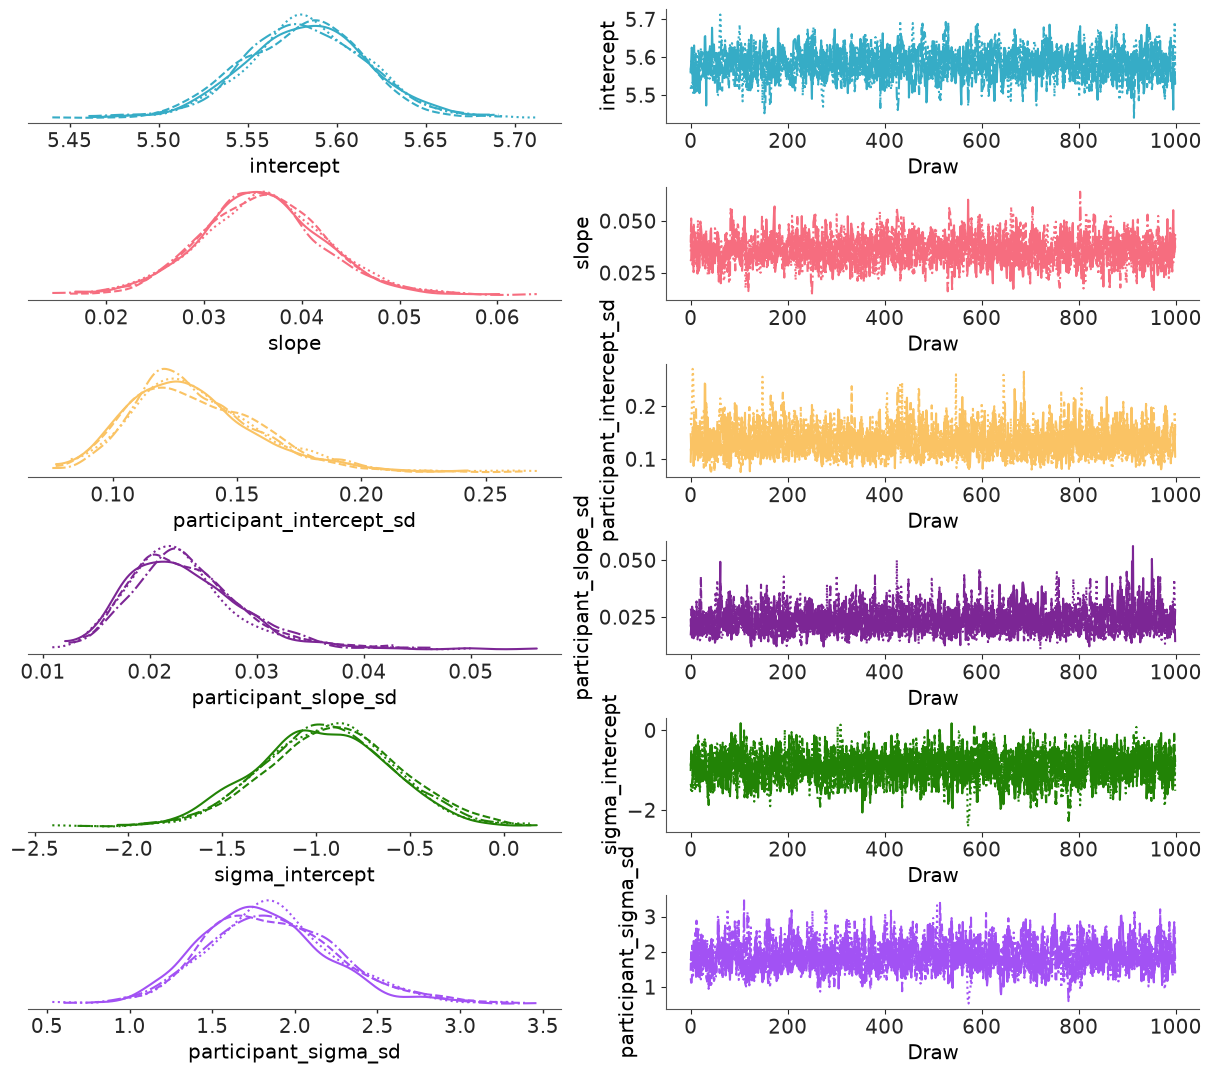

In [9]:
azp.plot_trace_dist(
    idata,
    var_names=["intercept", "slope", "participant_intercept_sd", "participant_slope_sd",
               "sigma_intercept", "participant_sigma_sd"],
);

This plot shows posterior uncertainty in the expected reaction time (on the millisecond scale) of a *typical* participant. It does not include between-participant or measurement-to-measurement variation.

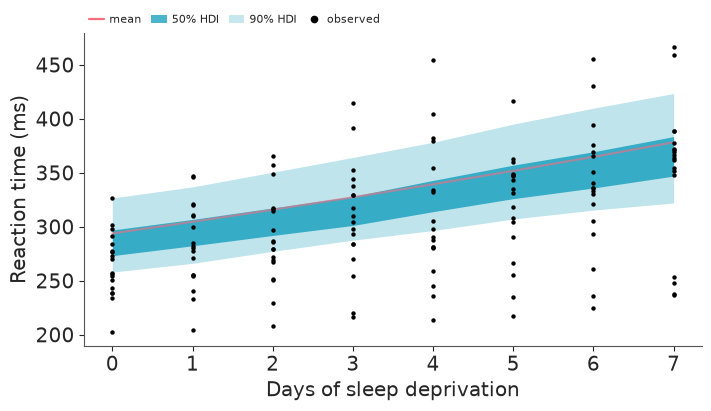

In [10]:
plot_population(idata, "population_mean_rt")
plt.show()

Each panel shows posterior uncertainty in that participant's expected reaction time. These are mean trajectories, not new measurements.

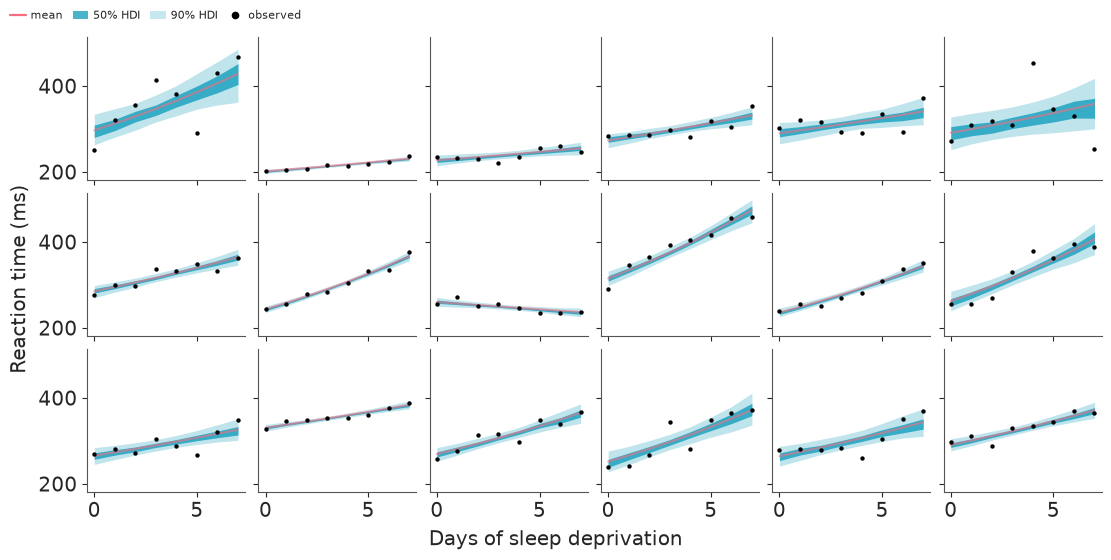

In [11]:
plot_participants(idata, "posterior", "mean_rt")
plt.show()

Posterior of each participant's residual SD on the log scale; roughly, the typical relative size of that person's day-to-day fluctuations.

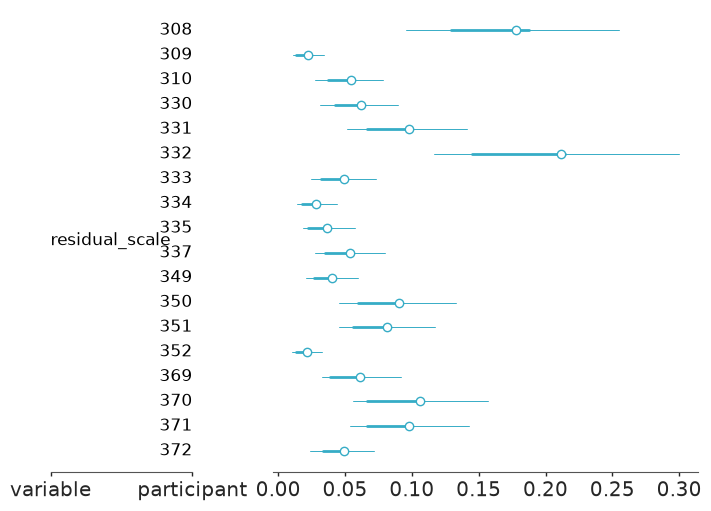

In [12]:
azp.plot_forest(
    idata, var_names=["residual_scale"], combined=True,
    point_estimate="mean", ci_kind="hdi", ci_probs=(0.50, 0.90),
    figure_kwargs={"figsize": (7, 5)},
);

## 8.3 Predictive value of heteroskedasticity

Does modeling participant-specific residual variability improve the predictive description of reaction times?

Now generate new reaction times from the fitted model. The layout is the same as in the prior predictive check; the difference is that these predictions are conditioned on the data. The bands are the distribution of a single new measurement for each participant and day.

Sampling: [Reaction]


D:\Repositories\BayesShortCourse\tmp\colabenv\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets"
for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

D:\Repositories\BayesShortCourse\tmp\colabenv\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets"
for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

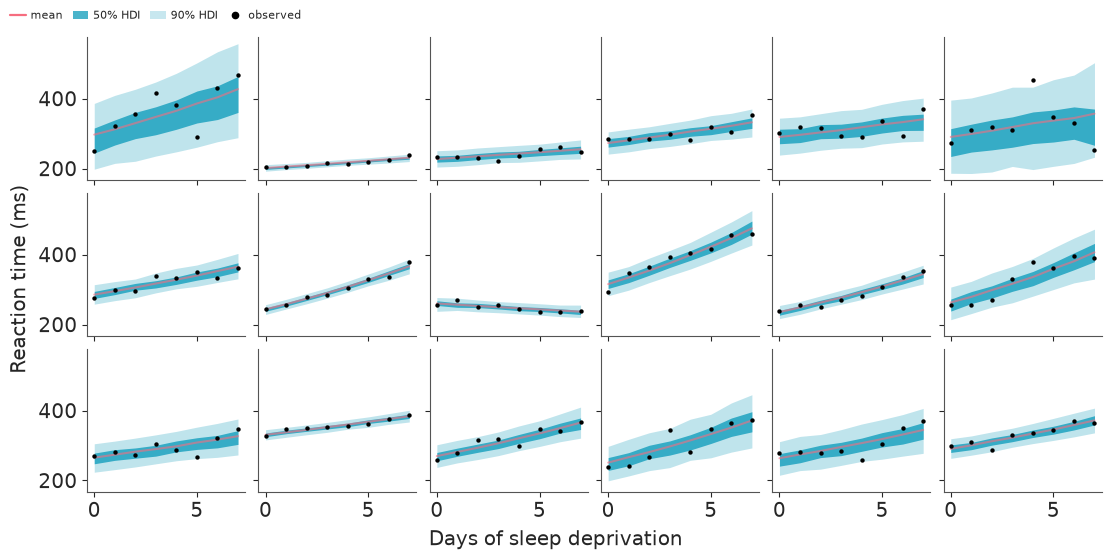

In [13]:
with model:
    pm.sample_posterior_predictive(
        idata, var_names=["Reaction"], extend_inferencedata=True, random_seed=RANDOM_SEED
    )

plot_participants(idata, "posterior_predictive", "Reaction")
plt.show()

The panel plot checks trajectories. This check pools all 144 measurements and asks whether simulated datasets reproduce the overall *shape* of the reaction-time distribution, especially its right tail.

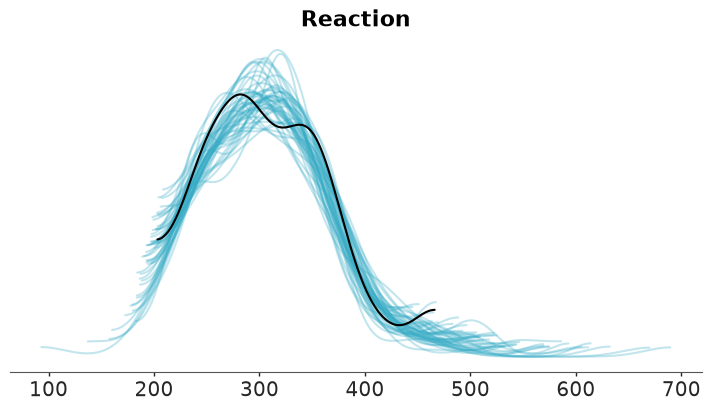

In [14]:
azp.plot_ppc_dist(idata, var_names=["Reaction"], kind="kde", figure_kwargs={"figsize": (7, 4)});

## 8.4 Eliciting scale hierarchies

What makes the residual-scale hierarchy difficult to specify scientifically?

Distributional models can describe heteroskedasticity, but their scale parameters live on transformed scales and are harder to elicit. The chapter next explores an ex-Gaussian likelihood, which represents right-skew directly as a Gaussian component plus an exponential tail.